# DDPG — Approach 1: gain SEARCH -> FREEZE -> CRITIC-EXPLOIT (critic from CQL)
Actor warm-started from BC; the exploit-phase critic is initialised from the trained CQL policy. Train + evaluate on Juan's 4 new days.

In [1]:
# ── Setup: shared library (../main_script) + this folder's config ────────────
import os, sys, copy, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
sys.path.insert(0, os.getcwd())                                            # for: import config
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # reach ../main_script
from main_script import *
import config as cfg
from config import *
configure(cfg); set_seed(SEED)

# ── TUNED gain box (per-notebook override; wider AND stability-safe) ─────────
# Back-calculation anti-windup is stable under pump saturation only if
# Kw*Ki*TS <= 2 (the saturated integrator update is int_e <- (1-Kw*Ki*TS)*int_e + ...).
# This box caps the worst-case product at |-0.4 * -4.0| = 1.6, so EVERY gain in
# the box is stable by construction. Found via gain-space exploration: vs the
# previous box ([-6,-0.1,-0.6]..[-0.05,-1e-4,0.1]) it cuts closed-loop MAE ~5x
# and undershoot ~4x, and lowers overshoot ~25%, at unchanged control effort.
cfg.GAIN_LOW = np.array([-30.0, -4.0, -0.4], dtype=np.float32)
UNDERSHOOT_WEIGHT = 0.15   # checkpoint selection: MAE + w*overshoot + w*undershoot

# ── Per-notebook choices ──
ALGO = "DDPG"
TWIN = False
agent  = DDPG(warm_start=True)
buffer = ReplayBuffer()

# ── Datasets + episode sampler (Juan's new days) ──
train_datasets   = [load_dataset(f) for f in JUAN_FILES]
VAL_FILE         = JUAN_FILES[-1]
episode_datasets = [load_dataset(f) for f in JUAN_FILES if f != VAL_FILE]
train_eval_days  = [d for d in train_datasets if d["name"] != VAL_FILE]
val_eval_days    = [d for d in train_datasets if d["name"] == VAL_FILE]
def get_episode_data(datasets, ep_steps=SHORT_EP_STEPS):
    w = np.array([2.0 if "Cloudy" in d["name"] else 1.0 for d in datasets]); w = w / w.sum()
    idx = int(np.random.choice(len(datasets), p=w)); full = datasets[idx]
    ms = max(0, full["N"] - ep_steps - 1); start = np.random.randint(0, ms + 1) if ms > 0 else 0
    return window(full, start, ep_steps)
print(f"[{ALGO}] agent ready | fine-tune on {len(episode_datasets)} Juan days; VAL={VAL_FILE}")
print(f"[{ALGO}] tuned gain box: LOW={list(cfg.GAIN_LOW)} HIGH={list(cfg.GAIN_HIGH)}")


[warm-start] BC trunk loaded from bc_cirl_setpoint_anti_windup_best.pt
[warm-start] head re-centred to START_GAIN Kp=-0.5 Ki=-0.00167


[DDPG] agent ready | fine-tune on 3 Juan days; VAL=19_06_2026__Sunny_Closed_Loop.xlsx
[DDPG] tuned gain box: LOW=[np.float32(-30.0), np.float32(-4.0), np.float32(-0.4)] HIGH=[np.float32(-0.05), np.float32(-1e-04), np.float32(0.1)]


In [2]:
# ── Initialise the critic FROM the trained CQL policy ────────────────────────
# "Critic from CQL": load the CQL actor, roll it out on Juan's data to build an
# offline buffer, then fit THIS agent's critic to evaluate that policy (TD policy
# evaluation). The online agent therefore STARTS with the CQL Q-function as its
# first critic — used by both approaches below.
CQL_CKPT           = 'cql_cirl_actor_best.pt'
CQL_PRETRAIN_STEPS = 8000
CQL_PRETRAIN_NOISE = 0.03

def load_cql_actor(ckpt=CQL_CKPT):
    a = Actor().to(DEVICE)
    a.load_state_dict(torch.load(os.path.join(SAVE_DIR, ckpt), map_location=DEVICE, weights_only=True))
    a.eval(); print(f"[cql] policy loaded from {ckpt}")
    return a

def fill_buffer_from_actor(actor_net, datasets, buf, noise_std=CQL_PRETRAIN_NOISE):
    actor_net.eval()
    with torch.no_grad():
        for ds in datasets:
            env = SolarFieldEnv(ds); obs = env.reset(); done = False
            while not done:
                s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a = actor_net(s).cpu().numpy()[0]
                a = np.clip(a + np.random.randn(3).astype(np.float32) * noise_std, 0.0, 1.0)
                obs2, r, done, info = env.step(a); buf.add(obs, a, r, obs2, done); obs = obs2
    return len(buf)

def pretrain_critic_from_cql(agent, cql_actor, datasets, n_updates=CQL_PRETRAIN_STEPS, batch=BATCH_SIZE):
    pre = ReplayBuffer(); n = fill_buffer_from_actor(cql_actor, datasets, pre)
    print(f"[cql-critic] {n} transitions from CQL rollouts; fitting critic for {n_updates} steps...")
    cql_actor.eval(); lc = torch.tensor(0.0)
    for it in range(1, n_updates + 1):
        s, a, r, s2, d = pre.sample(batch)
        with torch.no_grad():
            a2 = cql_actor(s2)                              # evaluate the CQL policy
            if TWIN:
                q1t, q2t = agent.critic_target(s2, a2); qt = r + agent.gamma * (1 - d) * torch.min(q1t, q2t)
            else:
                qt = r + agent.gamma * (1 - d) * agent.critic_target(s2, a2)
        if TWIN:
            q1, q2 = agent.critic(s, a); lc = F.mse_loss(q1, qt) + F.mse_loss(q2, qt)
        else:
            q = agent.critic(s, a); lc = F.mse_loss(q, qt)
        agent.opt_c.zero_grad(); lc.backward(); agent.opt_c.step()
        for tp, p in zip(agent.critic_target.parameters(), agent.critic.parameters()):
            tp.data.mul_(1 - agent.tau); tp.data.add_(agent.tau * p.data)
    print(f"[cql-critic] done; critic initialised as the CQL Q-function (final TD loss {float(lc):.4f}).")

cql_actor = load_cql_actor()
print("CQL critic-pretrain utilities ready.")


[cql] policy loaded from cql_cirl_actor_best.pt
CQL critic-pretrain utilities ready.


In [3]:
# ══════════ APPROACH 1: gain SEARCH -> FREEZE -> CRITIC-EXPLOIT ══════════
# Actor = BC warm-start; the EXPLOIT-phase critic is INITIALISED FROM CQL.
TAG = 'ddpg_online_ac_approach1'
SAVE_PATH = os.path.join(SAVE_DIR, f'{TAG}_best.pt')
pretrain_critic_from_cql(agent, cql_actor, episode_datasets)   # first critic = CQL Q-function

# -- STEP 4: SEARCH -> FREEZE -> CRITIC-EXPLOIT  (no hardcoded target) --
# Phase 1 SEARCH : adaptive (1+1)-ES around the best point; rank by
#                  REWARD - SEARCH_OVR_W*overshoot - SEARCH_UND_W*undershoot;
#                  radius GROWS on a hit, SHRINKS when stuck -> DISCOVERS gains.
# Phase 2 FREEZE : lock the discovered gains as the BC anchor and lock the MAE baseline.
# Phase 3 EXPLOIT: the critic (alpha>0) fine-tunes the actor to LOWER overshoot AND
#                  undershoot at fixed MAE -> where TD3 (twin critic) and DDPG differ.
import time
EVAL_WIN       = 2000
MAE_CAP_MARGIN = 1.05
SEARCH_SIGMA0  = 0.45          # initial exploration breadth (normalised gain space)
SEARCH_SIGMA1  = 0.01          # final breadth (radius floor)
SEARCH_GROW    = 1.5           # broaden the radius after an improvement (keep exploring while progressing)
SEARCH_SHRINK  = 0.6           # shrink the radius when no better point is found ...
SHRINK_PATIENCE= 3             # ... for this many consecutive misses -> exploit around the best point
SEARCH_OVR_W   = 0.5           # overshoot penalty in the SEARCH score
SEARCH_UND_W   = 0.5           # undershoot penalty in the SEARCH score (tuned: also minimise undershoot)
SEARCH_PLATEAU_PCT      = 0.0001  # SEARCH -> EXPLOIT once the search objective improves < this ...
SEARCH_PLATEAU_PATIENCE = 60    #   ... for this many consecutive epochs (replaces the fixed 150-ep split)
EARLY_STOP_PCT      = 0.0001    # STOP in EXPLOIT once val reward improves < this ...
EARLY_STOP_PATIENCE = 50       #   ... for this many consecutive epochs (hard cap = EPISODES epochs)
train_eval_days = [d for d in train_datasets if d['name'] != VAL_FILE]
val_eval_days   = [d for d in train_datasets if d['name'] == VAL_FILE]
agent.bc_weight = BC_GUIDE_WEIGHT

# ── undershoot-aware metrics (tuned): undershoot = worst dip below T_ref AFTER
#    the first crossing (so the initial morning climb is not counted) ──────────
def undershoot_metric(T, tref):
    above = np.nonzero(T >= tref)[0]
    return float(np.max(tref - T[above[0]:])) if len(above) else float(np.max(tref - T))

def eval_gain_und(gn, days, win=EVAL_WIN):
    """Constant normalised gains -> (mean MAE, worst overshoot, mean reward, worst undershoot)."""
    gn = np.asarray(gn, dtype=np.float32); maes=[]; ovrs=[]; rews=[]; unds=[]
    for dv in days:
        wd = window(dv, 0, min(win, dv['N'])); env = SolarFieldEnv(wd, dataset_tref(dv['name']))
        env.reset(); done=False; T=[]; rsum=0.0; n=0
        while not done:
            _, r, done, info = env.step(gn); T.append(info['Tout']); rsum += r; n += 1
        tr = dataset_tref(dv['name']); T = np.array(T)
        maes.append(mae_rmse(T, tr)[0]); ovrs.append(peak_overshoot(T, tr))
        rews.append(rsum / max(n, 1)); unds.append(undershoot_metric(T, tr))
    return float(np.mean(maes)), float(np.max(ovrs)), float(np.mean(rews)), float(np.max(unds))

def eval_actor_und(actor, days, win=EVAL_WIN):
    """Actor rollout -> (mean MAE, mean reward, mean overshoot, worst undershoot)."""
    maes=[]; rews=[]; ovrs=[]; unds=[]; actor.eval()
    for dv in days:
        wd = window(dv, 0, min(win, dv['N'])); env = SolarFieldEnv(wd, dataset_tref(dv['name']))
        obs = env.reset(); done=False; T=[]; rsum=0.0; n=0
        with torch.no_grad():
            while not done:
                s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                obs, r, done, info = env.step(actor(s).cpu().numpy()[0]); T.append(info['Tout']); rsum+=r; n+=1
        tr = dataset_tref(dv['name']); T = np.array(T)
        maes.append(mae_rmse(T, tr)[0]); rews.append(rsum/max(n,1))
        ovrs.append(peak_overshoot(T, tr)); unds.append(undershoot_metric(T, tr))
    return float(np.mean(maes)), float(np.mean(rews)), float(np.mean(ovrs)), float(np.max(unds))

rng = np.random.default_rng(SEED)
best_norm = normalize_gains(START_GAIN).astype(np.float32)        # START at the expert (no target given)
bm, bo, best_rew, bu = eval_gain_und(best_norm, train_eval_days)  # search ranks by REWARD penalised for ovr+und
best_score = best_rew - SEARCH_OVR_W * bo - SEARCH_UND_W * bu     # multi-objective: low MAE AND low ovr AND low und
search_sigma = SEARCH_SIGMA0; search_stall = 0                    # adaptive radius: grow on a hit, shrink when stuck
agent.bc_target = torch.tensor(best_norm, dtype=torch.float32, device=DEVICE).view(1, -1)

history = {'ep': [], 'train_reward': [], 'val_reward': [], 'train_mae': [], 'val_mae': [],
           'val_overshoot': [], 'Kp': [], 'Ki': [], 'Kw': []}
global_step = 0
noise = OUNoise(sigma=0.15, sigma_min=0.01, decay=0.999)
torch.save(agent.actor.state_dict(), SAVE_PATH)
best_val_obj = float('inf'); best_ovr_und = float('inf'); MAE_CAP = float('inf'); best_exploit_rew = -1e9; stall = 0
searching = True; search_ref = best_score; search_plateau = 0   # dynamic SEARCH->EXPLOIT on reward plateau
print(f"Phase1 SEARCH until reward plateau (<{SEARCH_PLATEAU_PCT:.0%} for {SEARCH_PLATEAU_PATIENCE} ep) -> FREEZE -> "
      f"EXPLOIT; STOP at <{EARLY_STOP_PCT:.1%} for {EARLY_STOP_PATIENCE} ep (max {EPISODES}).")
print(f"Start (expert): MAE={bm:.3f} overshoot={bo:.3f} undershoot={bu:.3f}  (NO target hardcoded)\n")

_t0 = time.time()
for ep in range(1, EPISODES + 1):
    froze_now = False
    if searching:
        # ep 1 = the expert warm-start itself; search proposes from ep 2 on
        if ep > 1:
            # sample around the BEST-score point; re-center on it; adapt the radius to the result
            cand = np.clip(best_norm + rng.normal(0, search_sigma, 3).astype(np.float32), 0.0, 1.0)
            cm, co, cr, cu = eval_gain_und(cand, train_eval_days)
            cscore = cr - SEARCH_OVR_W * co - SEARCH_UND_W * cu   # low MAE AND low overshoot AND low undershoot
            if cscore > best_score:                 # better trade-off -> new best operating point
                best_score, best_rew, best_norm = cscore, cr, cand
                search_sigma = min(search_sigma * SEARCH_GROW, SEARCH_SIGMA0)   # progressing -> broaden
                search_stall = 0
            else:
                search_stall += 1                   # missed this try
                if search_stall >= SHRINK_PATIENCE: # can't improve -> SHRINK to exploit around the best
                    search_sigma = max(search_sigma * SEARCH_SHRINK, SEARCH_SIGMA1)
                    search_stall = 0
            # plateau test: search objective improved < SEARCH_PLATEAU_PCT -> count toward FREEZE
            if best_score > search_ref + abs(search_ref) * SEARCH_PLATEAU_PCT:
                search_ref = best_score; search_plateau = 0
            else:
                search_plateau += 1
            froze_now = search_plateau >= SEARCH_PLATEAU_PATIENCE   # plateaued -> switch to EXPLOIT now
        agent.bc_target = torch.tensor(best_norm, dtype=torch.float32, device=DEVICE).view(1, -1)
        agent.bc_alpha = 0.0                       # critic warms up only
        noise.reset(); use_noise = noise
    else:
        agent.bc_alpha = RL_FINE_ALPHA             # exploit: critic nudges the actor (frozen anchor)
        use_noise = None

    data = get_episode_data(episode_datasets, SHORT_EP_STEPS); env = SolarFieldEnv(data)
    obs = env.reset(); done=False; gsum=np.zeros(3); steps=0
    while not done:
        a = agent.act(obs, noise=use_noise)
        obs2, r, done, info = env.step(a); buffer.add(obs, a, r, obs2, done)
        gsum += denormalize_gains(a); global_step += 1
        if global_step >= WARMUP_STEPS and global_step % UPDATE_EVERY == 0:
            for _ in range(UPDATES_PER_CYCLE): agent.update(buffer, BATCH_SIZE)
        obs = obs2; steps += 1
        if use_noise is not None: noise.step()
    mg = gsum / max(steps, 1)

    tm, tr_, to = eval_actor(agent.actor, train_eval_days)
    vm, vr, vo, vu = eval_actor_und(agent.actor, val_eval_days)
    history['ep'].append(ep); history['train_reward'].append(tr_); history['val_reward'].append(vr)
    history['train_mae'].append(tm); history['val_mae'].append(vm); history['val_overshoot'].append(vo)
    history['Kp'].append(mg[0]); history['Ki'].append(mg[1]); history['Kw'].append(mg[2])

    # checkpoint: improve during search; lock baseline at the freeze; minimise ovr+und in exploit
    tag = ''; vobj = vm + OVERSHOOT_WEIGHT * vo + UNDERSHOOT_WEIGHT * vu
    if searching and not froze_now:
        if vobj < best_val_obj:
            best_val_obj = vobj
            torch.save(agent.actor.state_dict(), SAVE_PATH); tag = '  <- saved (search)'
    elif froze_now:
        searching = False; MAE_CAP = vm * MAE_CAP_MARGIN
        best_ovr_und = vo + (UNDERSHOOT_WEIGHT / OVERSHOOT_WEIGHT) * vu
        torch.save(agent.actor.state_dict(), SAVE_PATH); tag = f'  <- FROZEN; MAE baseline {vm:.3f}'
    else:
        cur_ovr_und = vo + (UNDERSHOOT_WEIGHT / OVERSHOOT_WEIGHT) * vu
        if vm <= MAE_CAP and cur_ovr_und < best_ovr_und:
            best_ovr_und = cur_ovr_und
            torch.save(agent.actor.state_dict(), SAVE_PATH); tag = '  <- lower ovr/und (saved)'

    # early-stop the EXPLOIT phase once the val reward plateaus (< EARLY_STOP_PCT change)
    stop_now = False
    if not searching and not froze_now:
        if vr > best_exploit_rew + abs(best_exploit_rew) * EARLY_STOP_PCT:
            best_exploit_rew = vr; stall = 0
        else:
            stall += 1; stop_now = stall >= EARLY_STOP_PATIENCE

    if ep % EVAL_EVERY == 0 or ep == 1 or froze_now or stop_now:
        dg = denormalize_gains(best_norm); ph = 'SRCH' if searching else 'XPLT'
        print(f"Ep {ep:3d} [{ph}] | sig={search_sigma:.3f} | FOUND Kp={dg[0]:+.3f} Ki={dg[1]:+.5f} Kw={dg[2]:+.4f} "
              f"| train_rew={tr_:.4f} val_rew={vr:.4f} | val MAE={vm:.3f} ovr={vo:.3f} und={vu:.3f}{tag}")
    if stop_now:
        print(f"EARLY STOP at ep {ep}: val reward improved < {EARLY_STOP_PCT:.1%} for {EARLY_STOP_PATIENCE} consecutive epochs."); break

dg = denormalize_gains(best_norm)
print(f"\nDone in {(time.time()-_t0)/60:.1f} min. DISCOVERED gains (found by search, not given): "
      f"Kp={dg[0]:.3f} Ki={dg[1]:.5f} Kw={dg[2]:.4f}")
print("Plot the reward/gain curves next, then STEP 5 for the full-day result.")


[cql-critic] 55185 transitions from CQL rollouts; fitting critic for 8000 steps...


[cql-critic] done; critic initialised as the CQL Q-function (final TD loss 2.5308).


Phase1 SEARCH until reward plateau (<0% for 60 ep) -> FREEZE -> EXPLOIT; STOP at <0.0% for 50 ep (max 300).
Start (expert): MAE=1.377 overshoot=5.425 undershoot=4.796  (NO target hardcoded)



Ep   1 [SRCH] | sig=0.450 | FOUND Kp=-0.500 Ki=-0.00167 Kw=+0.0033 | train_rew=1.1012 val_rew=2.2798 | val MAE=0.831 ovr=4.936 und=0.225  <- saved (search)


Ep  10 [SRCH] | sig=0.450 | FOUND Kp=-28.901 Ki=-2.38721 Kw=-0.2144 | train_rew=8.5451 val_rew=8.8589 | val MAE=0.043 ovr=2.302 und=0.222  <- saved (search)


...

Ep 100 [XPLT] | sig=0.010 | FOUND Kp=-30.000 Ki=-4.00000 Kw=-0.4000 | train_rew=8.6308 val_rew=8.9039 | val MAE=0.042 ovr=2.249 und=0.278


Ep 110 [XPLT] | sig=0.010 | FOUND Kp=-30.000 Ki=-4.00000 Kw=-0.4000 | train_rew=8.6308 val_rew=8.9039 | val MAE=0.042 ovr=2.249 und=0.278


Ep 120 [XPLT] | sig=0.010 | FOUND Kp=-30.000 Ki=-4.00000 Kw=-0.4000 | train_rew=8.6308 val_rew=8.9039 | val MAE=0.042 ovr=2.249 und=0.278


Ep 130 [XPLT] | sig=0.010 | FOUND Kp=-30.000 Ki=-4.00000 Kw=-0.4000 | train_rew=8.6308 val_rew=8.9039 | val MAE=0.042 ovr=2.249 und=0.278


Ep 133 [XPLT] | sig=0.010 | FOUND Kp=-30.000 Ki=-4.00000 Kw=-0.4000 | train_rew=8.6308 val_rew=8.9039 | val MAE=0.042 ovr=2.249 und=0.278
EARLY STOP at ep 133: val reward improved < 0.0% for 50 consecutive epochs.

Done in 11.0 min. DISCOVERED gains (found by search, not given): Kp=-30.000 Ki=-4.00000 Kw=-0.4000
Plot the reward/gain curves next, then STEP 5 for the full-day result.


In [4]:
# ── Final evaluation on Juan's days (deterministic rollout of the best actor) ──
def rollout_full(actor, data, tref=None):
    env = SolarFieldEnv(data, tref); obs = env.reset(); done = False
    T=[]; Q=[]; G=[]; actor.eval()
    with torch.no_grad():
        while not done:
            s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a = actor(s).cpu().numpy()[0]; G.append(denormalize_gains(a))
            obs, r, done, info = env.step(a); T.append(info['Tout']); Q.append(info['q'])
    return np.array(T), np.array(Q), np.array(G)

best_actor = Actor().to(DEVICE)
best_actor.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)); best_actor.eval()

print(f"{'Juan day':40s} | {TAG} MAE   RMSE   ovr    und | Expert MAE   ovr    und")
print('-' * 108)
rows = []
for ds in train_datasets:
    tr = dataset_tref(ds['name'])
    T, Q, G   = rollout_full(best_actor, ds)
    Te, Qe    = rollout_expert(ds)
    m, rm     = mae_rmse(T, tr);  ov  = peak_overshoot(T, tr);  un  = undershoot_metric(T, tr)
    me, rme   = mae_rmse(Te, tr); ove = peak_overshoot(Te, tr); une = undershoot_metric(Te, tr)
    rows.append((ds['name'], m, rm, ov, un, me, ove, une))
    print(f"{ds['name']:40s} | {m:6.3f} {rm:6.3f} {ov:6.3f} {un:6.3f} | {me:6.3f} {ove:6.3f} {une:6.3f}")
print('-' * 108)
print("MEAN over Juan days:  %s MAE=%.3f RMSE=%.3f ovr=%.3f und=%.3f  |  Expert MAE=%.3f ovr=%.3f und=%.3f"
      % (TAG, np.mean([r[1] for r in rows]), np.mean([r[2] for r in rows]), np.mean([r[3] for r in rows]),
         np.mean([r[4] for r in rows]),
         np.mean([r[5] for r in rows]), np.mean([r[6] for r in rows]), np.mean([r[7] for r in rows])))


Juan day                                 | ddpg_online_ac_approach1 MAE   RMSE   ovr    und | Expert MAE   ovr    und
------------------------------------------------------------------------------------------------------------


16_06_2026__Sunny_Closed_Loop.xlsx       |  0.012  0.102  2.519  0.265 |  1.286  5.425  5.972


17_06_2026__Sunny_Closed_Loop.xlsx       |  0.043  0.546  0.453  0.219 |  1.482  5.117  7.945


18_06_2026__Sunny_Closed_Loop.xlsx       |  0.025  0.182  2.794  0.266 |  1.796  8.219  6.434


19_06_2026__Sunny_Closed_Loop.xlsx       |  0.006  0.096  2.250  0.278 |  0.331  4.935  1.351
------------------------------------------------------------------------------------------------------------
MEAN over Juan days:  ddpg_online_ac_approach1 MAE=0.022 RMSE=0.232 ovr=2.004 und=0.257  |  Expert MAE=1.224 ovr=5.924 und=5.425


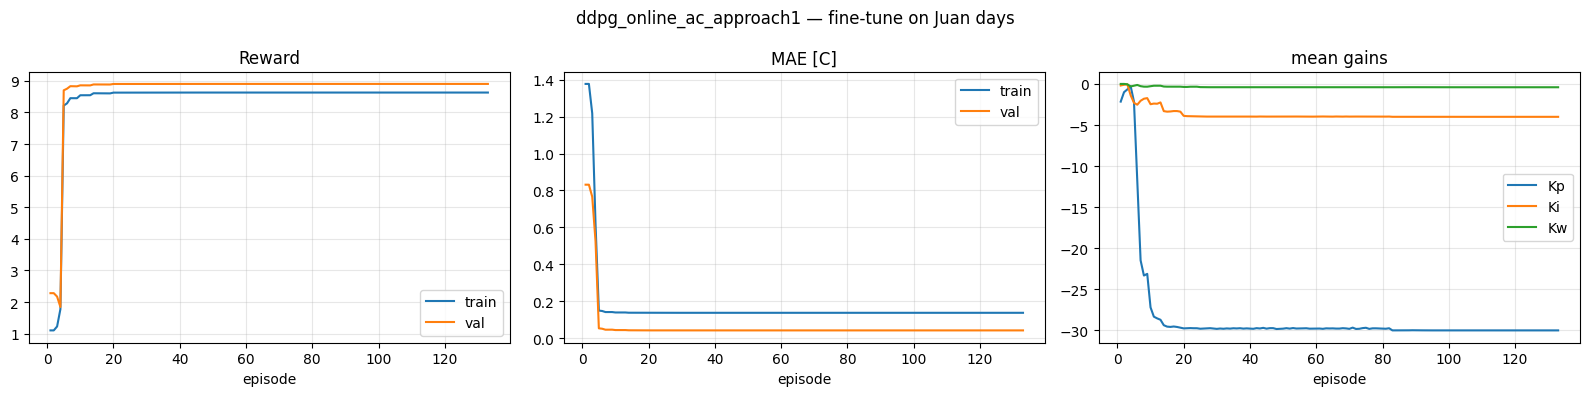

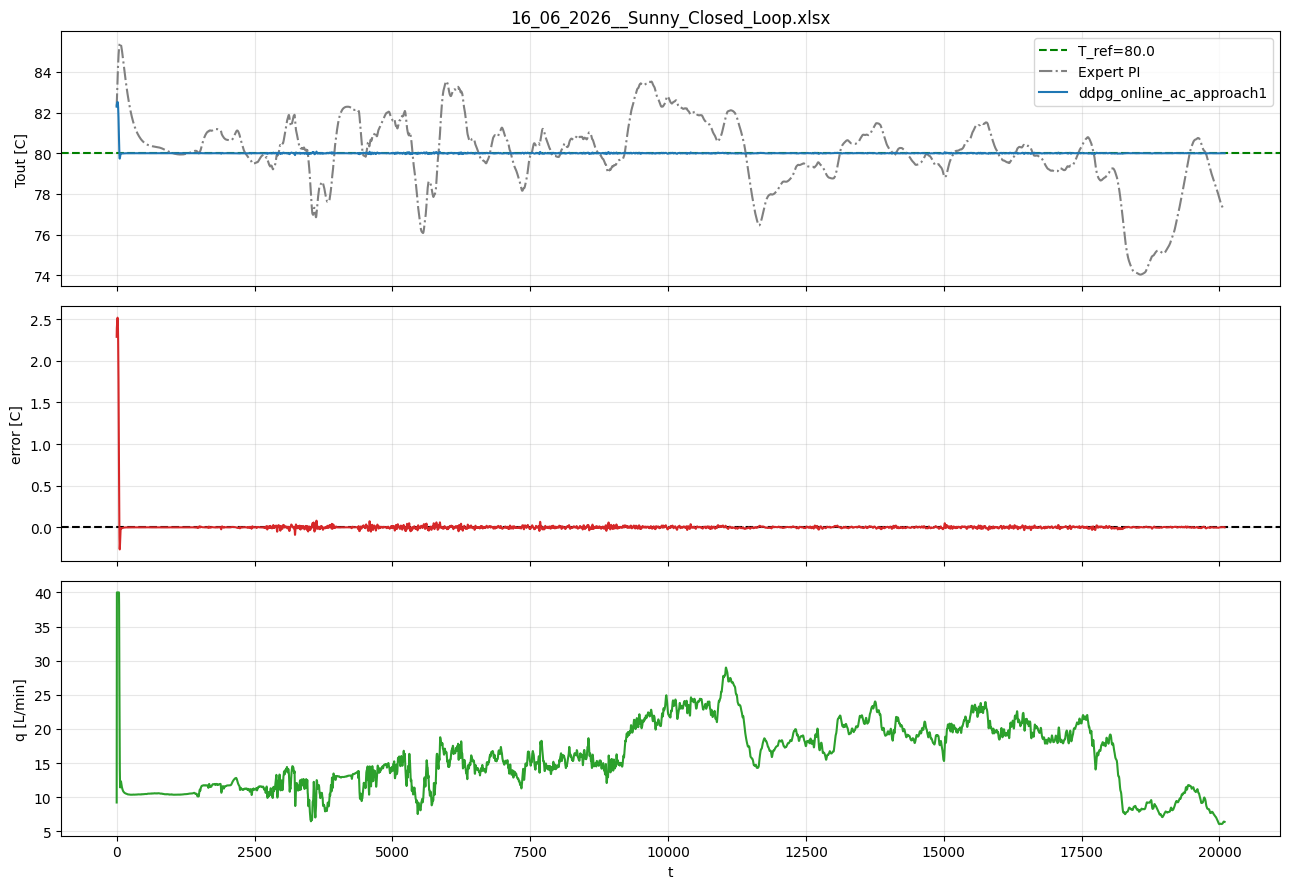

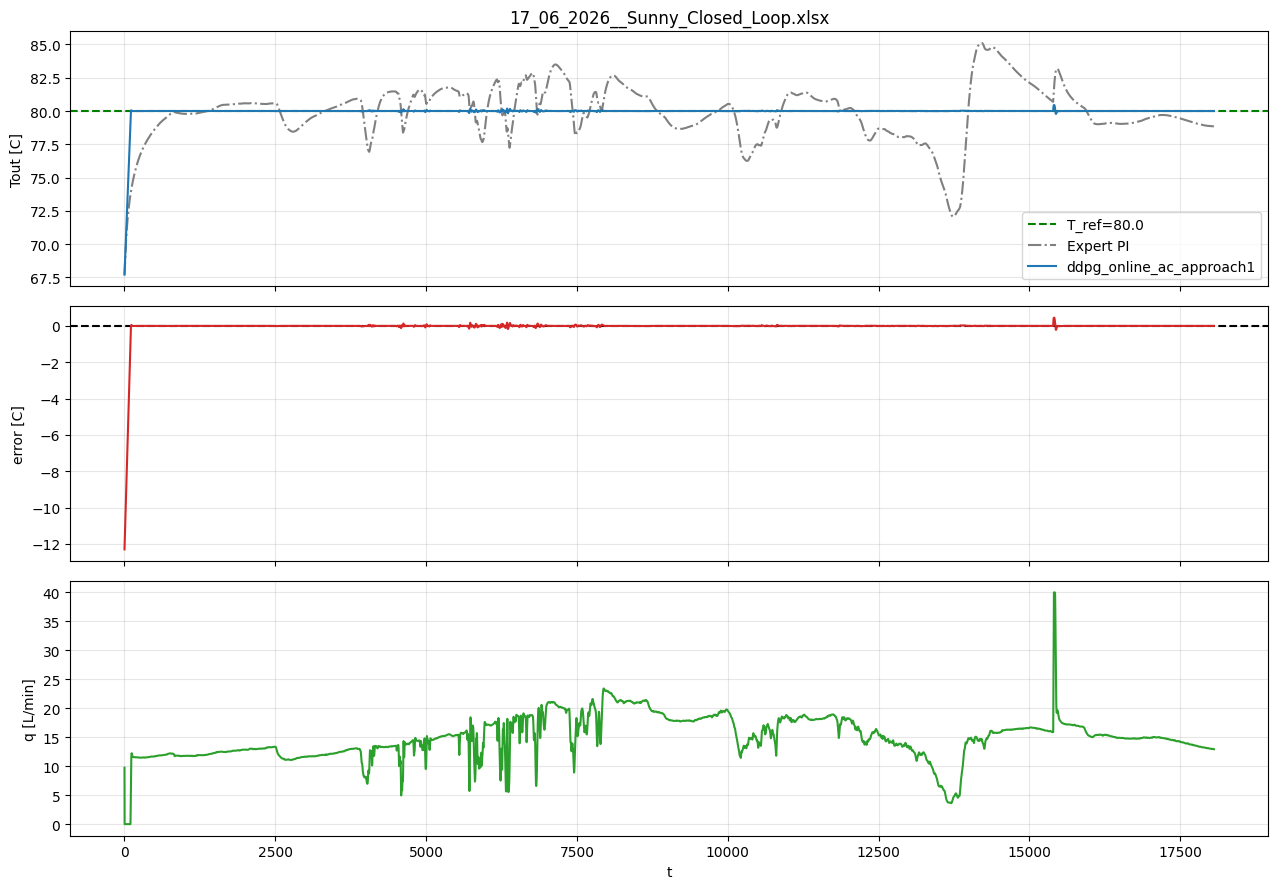

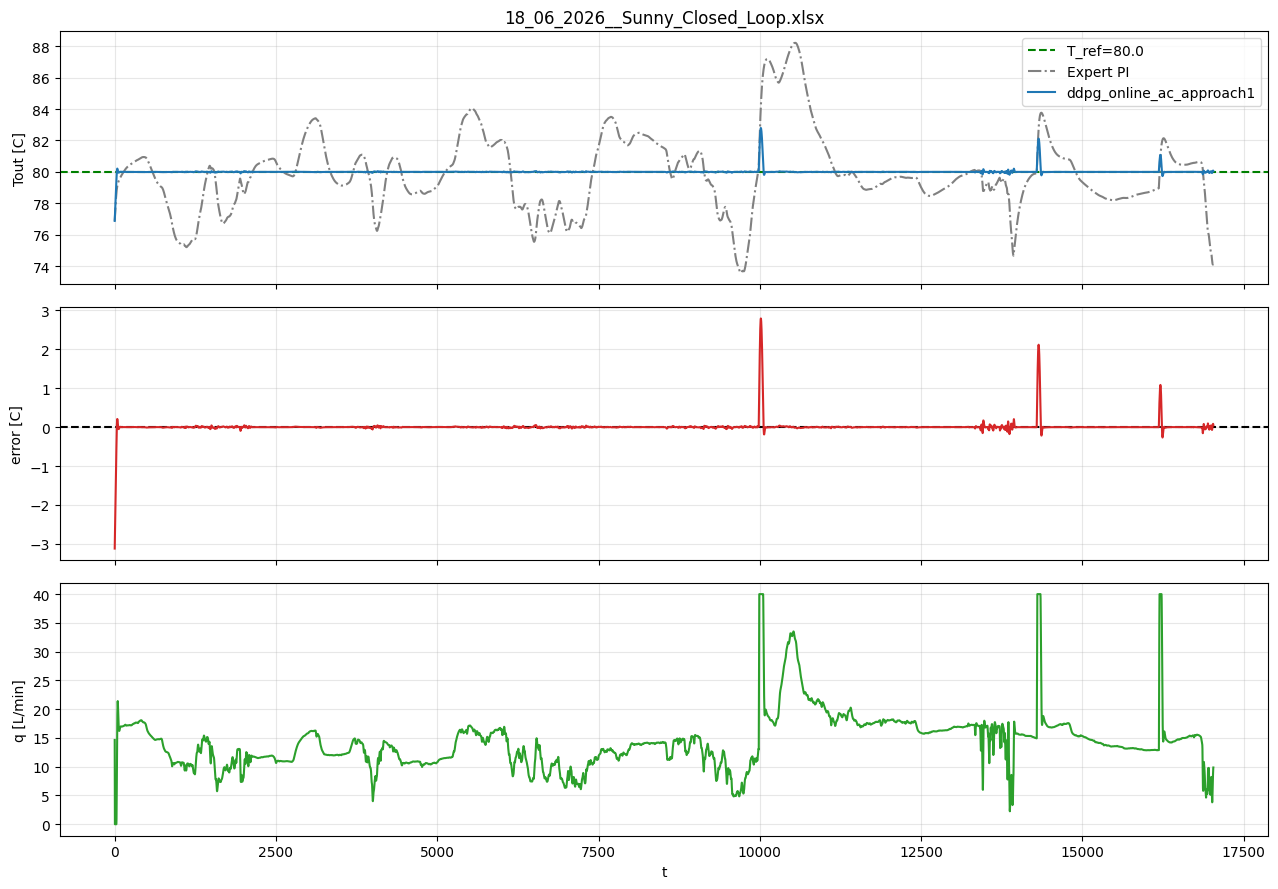

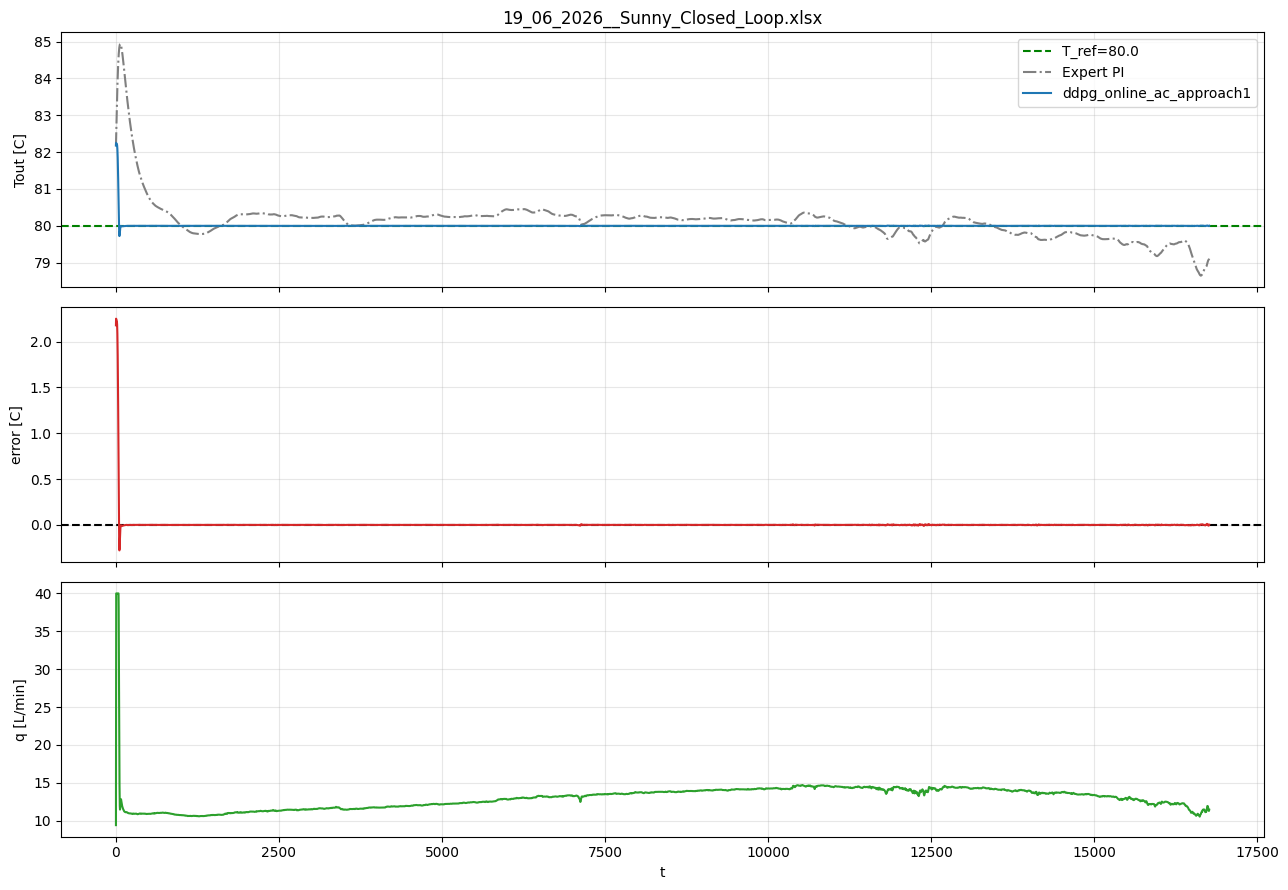

In [5]:
# ── Fine-tune curves + per-Juan-day tracking ─────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(history['ep'], history['train_reward'], label='train'); ax[0].plot(history['ep'], history['val_reward'], label='val')
ax[0].set_title('Reward'); ax[0].set_xlabel('episode'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(history['ep'], history['train_mae'], label='train'); ax[1].plot(history['ep'], history['val_mae'], label='val')
ax[1].set_title('MAE [C]'); ax[1].set_xlabel('episode'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(history['ep'], history['Kp'], label='Kp'); ax[2].plot(history['ep'], history['Ki'], label='Ki'); ax[2].plot(history['ep'], history['Kw'], label='Kw')
ax[2].set_title('mean gains'); ax[2].set_xlabel('episode'); ax[2].legend(); ax[2].grid(alpha=.3)
fig.suptitle(f'{TAG} — fine-tune on Juan days'); fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, f'{TAG}_curves.png'), dpi=150); plt.show()

for ds in train_datasets:
    tr = dataset_tref(ds['name']); T, Q, G = rollout_full(best_actor, ds); Te, Qe = rollout_expert(ds)
    t = np.arange(len(T))
    fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    ax[0].axhline(tr, ls='--', c='g', label=f'T_ref={tr}'); ax[0].plot(t, Te[:len(T)], c='gray', ls='-.', label='Expert PI')
    ax[0].plot(t, T, c='C0', label=TAG); ax[0].set_ylabel('Tout [C]'); ax[0].set_title(ds['name']); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].axhline(0, c='k', ls='--'); ax[1].plot(t, T - tr, c='C3'); ax[1].set_ylabel('error [C]'); ax[1].grid(alpha=.3)
    ax[2].plot(t, Q, c='C2'); ax[2].set_ylabel('q [L/min]'); ax[2].set_xlabel('t'); ax[2].grid(alpha=.3)
    fig.tight_layout()
    lbl = "_".join(ds['name'].split("_")[:3])
    fig.savefig(os.path.join(CHART_DIR, f'{TAG}_day_{lbl}.png'), dpi=140); plt.show()
